In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1 Category Contribution Analysis

In [2]:
df = pd.read_csv("../Data/category_sales.csv")
df.columns = ["CategoryName", "CategorySales"]
df['Contribution_%'] = df['CategorySales'] / df['CategorySales'].sum() * 100
print(df)

  CategoryName  CategorySales  Contribution_%
0   Components   1.180259e+07       77.673124
1     Clothing   2.120543e+06       13.955337
2  Accessories   1.272073e+06        8.371539


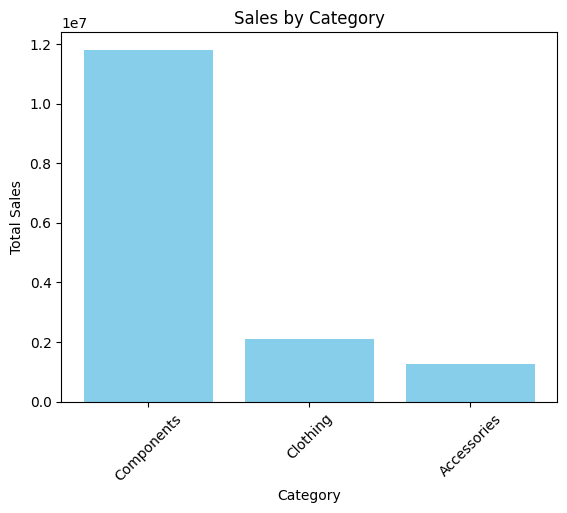

In [3]:
plt.figure()
plt.bar(df['CategoryName'], df['CategorySales'], color='skyblue')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

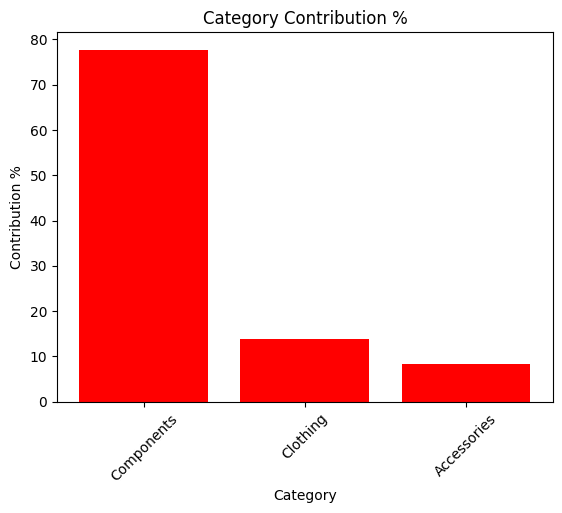

In [4]:
plt.figure()
plt.bar(df['CategoryName'], df['Contribution_%'], color='red')
plt.title("Category Contribution %")
plt.xlabel("Category")
plt.ylabel("Contribution %")
plt.xticks(rotation=45)
plt.show()

## 2 Best Selling Product per Category

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Data/best_product_category.csv")
df.columns = ["CategoryName", "ProductName", "TotalSales"]
print(df)

  CategoryName                     ProductName    TotalSales
0   Components  HL Mountain Frame - Silver, 38  930780.68070
1  Accessories             Hitch Rack - 4-Bike  237096.15600
2     Clothing      Long-Sleeve Logo Jersey, L  198754.97536


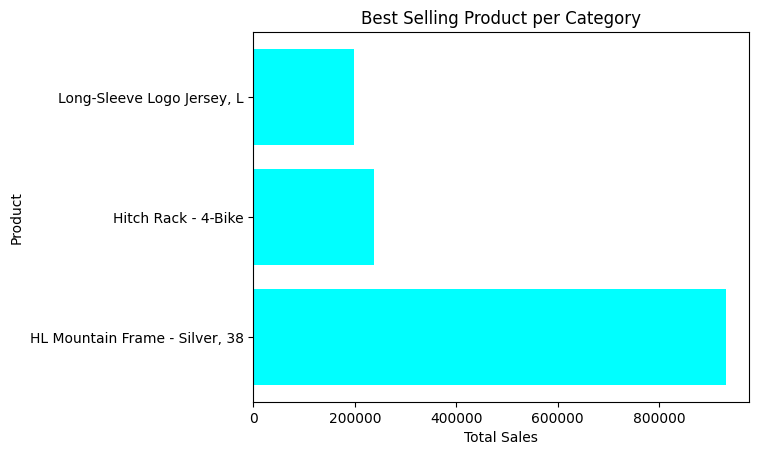

In [6]:
plt.figure()
plt.barh(df['ProductName'], df['TotalSales'], color='aqua')
plt.title("Best Selling Product per Category")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

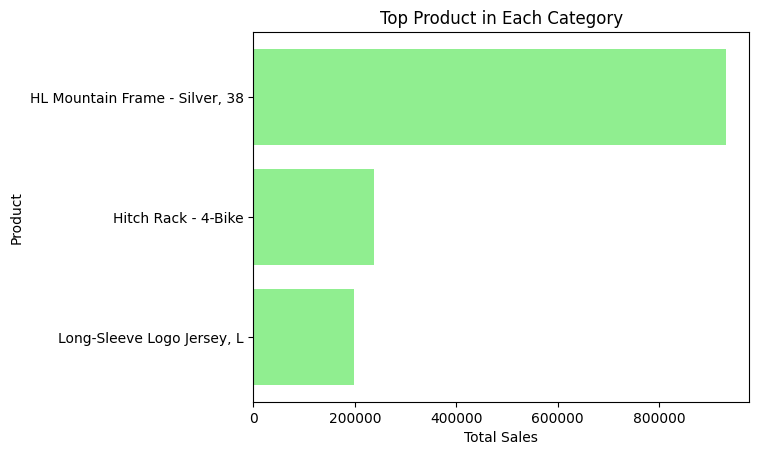

In [7]:
df = df.sort_values(by='TotalSales', ascending=True)
plt.figure()
plt.barh(df['ProductName'], df['TotalSales'], color='lightgreen')
plt.title("Top Product in Each Category")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

# 3 Monthly Sales Trend

In [8]:
df = pd.read_csv("../Data/monthly_sales.csv", header=None)
df.columns = ['Year', 'Month', 'TotalSales']
print(df.head())

   Year  Month    TotalSales
0  2022      5  5.824153e+05
1  2022      6  2.244313e+06
2  2022      7  1.868508e+06
3  2022      8  1.483277e+06
4  2022      9  3.183714e+06


In [9]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df = df.sort_values('Date')

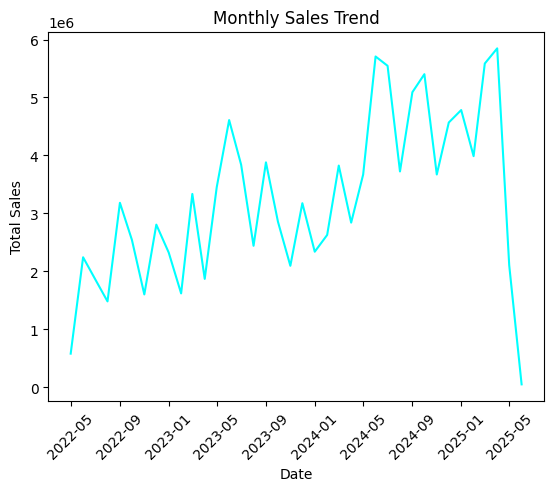

In [10]:
plt.figure()
plt.plot(df['Date'], df['TotalSales'],color='aqua')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# 4 Year-over-Year Growth

In [11]:
df = pd.read_csv("../Data/yearly_sales.csv", header=None)
df.columns = ['Year', 'TotalSales']
df = df.sort_values('Year')
df['YoY_%'] = df['TotalSales'].pct_change() * 100
print(df)

   Year    TotalSales       YoY_%
0  2022  1.631669e+07         NaN
1  2023  3.551471e+07  117.658708
2  2024  4.902049e+07   38.028700
3  2025  2.236490e+07  -54.376422


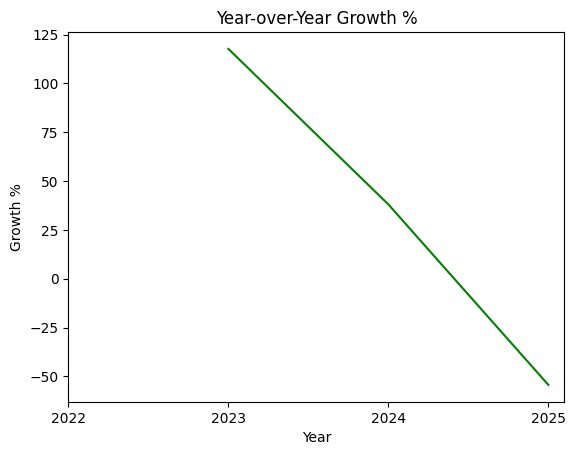

In [12]:
plt.figure()
plt.plot(df['Year'], df['YoY_%'],color='green')
plt.title("Year-over-Year Growth %")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.xticks(df['Year'])
plt.show()

# 5 Top 10 Customers

In [13]:
df = pd.read_csv("../Data/top_customers.csv", header=None)
df.columns = ['CustomerID', 'CustomerName', 'TotalSales']
print(df)

   CustomerID        CustomerName   TotalSales
0       29818         Roger Harui  989184.0820
1       29715        Andrew Dixon  961675.8596
2       29722         Reuben D'sa  954021.9235
3       30117        Robert Vessa  919801.8188
4       29614       Ryan Calafato  901346.8560
5       29639  Joseph Castellucio  887090.4106
6       29701       Kirk DeGrasse  841866.5522
7       29617     Lindsey Camacho  834475.9271
8       29994      Robin McGuigan  824331.7682
9       29646    Stacey Cereghino  820383.5466


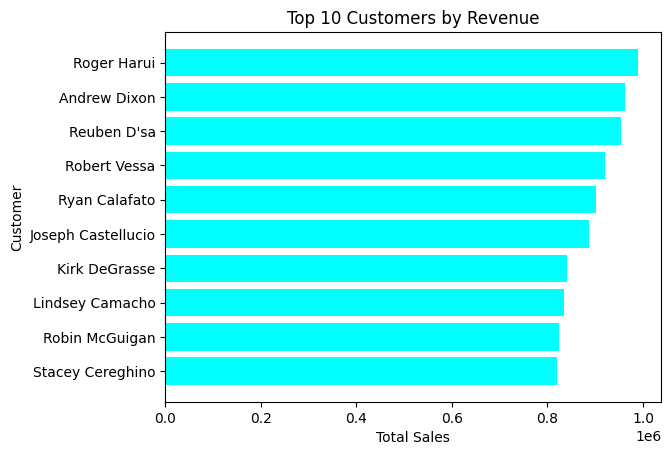

In [14]:
plt.figure()
plt.barh(df['CustomerName'], df['TotalSales'],color='aqua')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.gca().invert_yaxis()
plt.show()

# 6 Customer Segmentation (High / Medium / Low)

In [15]:
df = pd.read_csv("../Data/customer_total_sales.csv", header=None)
df.columns = ['CustomerID', 'TotalSales']
df['Segment'] = pd.qcut(df['TotalSales'], q=3, labels=['Low', 'Medium', 'High'])
print(df.head())

   CustomerID   TotalSales Segment
0       29818  989184.0820    High
1       29715  961675.8596    High
2       29722  954021.9235    High
3       30117  919801.8188    High
4       29614  901346.8560    High


In [16]:
segment_count = df['Segment'].value_counts()
print(segment_count)

Segment
Medium    6396
Low       6392
High      6331
Name: count, dtype: int64


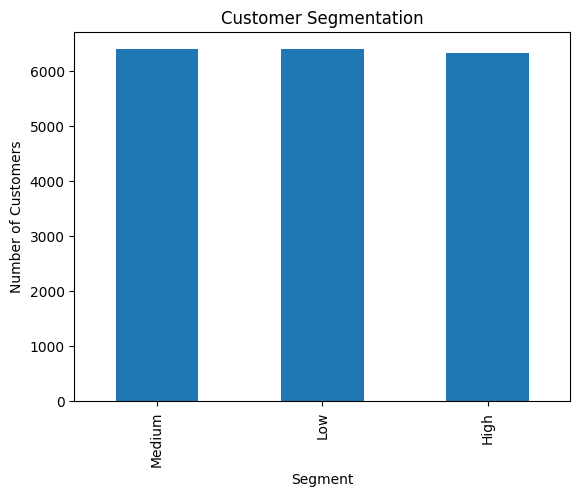

In [17]:
plt.figure()
segment_count.plot(kind='bar')
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

## 7 Sales by Territory / Region


In [18]:
df = pd.read_csv("../Data/sales_by_territory.csv", header=None)
df.columns = ['Territory', 'TotalSales']
print(df)

        Territory    TotalSales
0       Southwest  2.715059e+07
1          Canada  1.839893e+07
2       Northwest  1.806166e+07
3       Australia  1.181438e+07
4         Central  8.913299e+06
5       Southeast  8.884099e+06
6  United Kingdom  8.574049e+06
7          France  8.119749e+06
8       Northeast  7.820210e+06
9         Germany  5.479820e+06


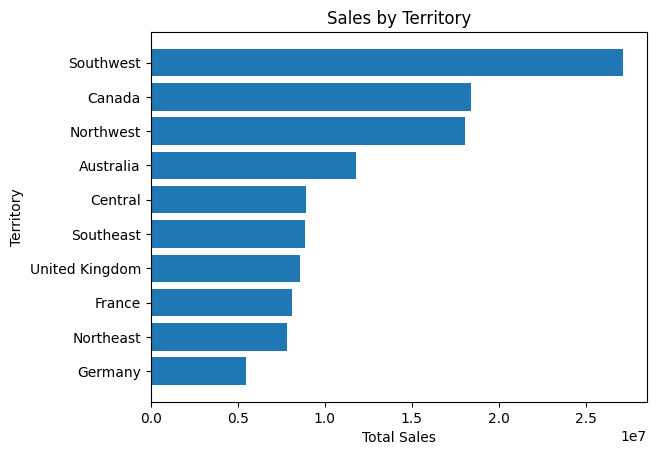

In [19]:
df = df.sort_values(by='TotalSales', ascending=True)
plt.figure()
plt.barh(df['Territory'], df['TotalSales'])
plt.title("Sales by Territory")
plt.xlabel("Total Sales")
plt.ylabel("Territory")
plt.show()

# 8 Average Order Value (AOV)


In [20]:
df = pd.read_csv("../Data/customer_aov.csv", header=None)
df.columns = ['CustomerID', 'TotalOrders', 'TotalSales', 'AOV']
print(df.describe())

         CustomerID   TotalOrders     TotalSales            AOV
count  19119.000000  19119.000000   19119.000000   19119.000000
mean   20559.000000      1.645745    6444.729647    1678.117817
std     5519.324234      1.457054   43756.276004    6034.784979
min    11000.000000      1.000000       1.518300       1.518300
25%    15779.500000      1.000000      60.752900      45.829850
50%    20559.000000      1.000000     606.622900     606.622900
75%    25338.500000      2.000000    3119.149400    2152.834200
max    30118.000000     28.000000  989184.082000  151704.902100


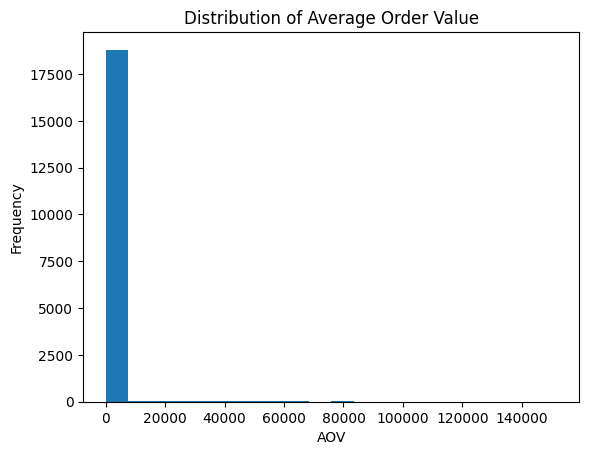

In [21]:
plt.figure()
plt.hist(df['AOV'], bins=20)
plt.title("Distribution of Average Order Value")
plt.xlabel("AOV")
plt.ylabel("Frequency")
plt.show()

# 9 Product Performance Analysis

In [22]:
df = pd.read_csv("../Data/bottom_products.csv", header=None)
df.columns = ['ProductID', 'ProductName', 'TotalSales']
print(df)

   ProductID                       ProductName  TotalSales
0        911               LL Road Seat/Saddle     162.720
1        710            Mountain Bike Socks, L     513.000
2        897       LL Touring Frame - Blue, 58     800.208
3        943     LL Mountain Frame - Black, 40    1198.992
4        914            LL Touring Seat/Saddle    1480.752
5        942  ML Mountain Frame-W - Silver, 38    1529.178
6        946             LL Touring Handlebars    1548.624
7        805                        LL Headset    1949.400
8        915            ML Touring Seat/Saddle    1972.656
9        927     LL Mountain Frame - Black, 52    2248.110


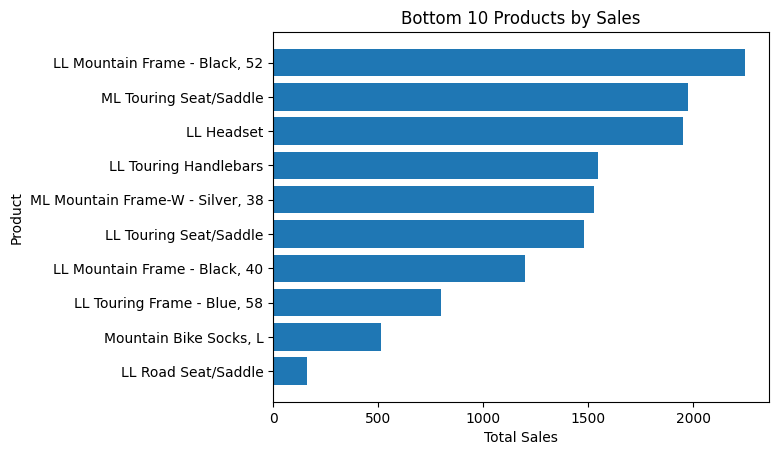

In [23]:
df = df.sort_values(by='TotalSales', ascending=True)
plt.figure()
plt.barh(df['ProductName'], df['TotalSales'])
plt.title("Bottom 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

# 10 Pareto Analysis (80/20 Rule)


In [24]:
df = pd.read_csv("../Data/product_sales.csv", header=None)
df.columns = ['ProductID', 'ProductName', 'Sales']
df = df.sort_values(by='Sales', ascending=False)
df['CumSales%'] = df['Sales'].cumsum() / df['Sales'].sum() * 100
print(df.head())

   ProductID              ProductName         Sales  CumSales%
0        782   Mountain-200 Black, 38  4.400593e+06   4.006134
1        783   Mountain-200 Black, 42  4.009495e+06   7.656226
2        779  Mountain-200 Silver, 38  3.693678e+06  11.018811
3        780  Mountain-200 Silver, 42  3.438479e+06  14.149073
4        781  Mountain-200 Silver, 46  3.434257e+06  17.275491


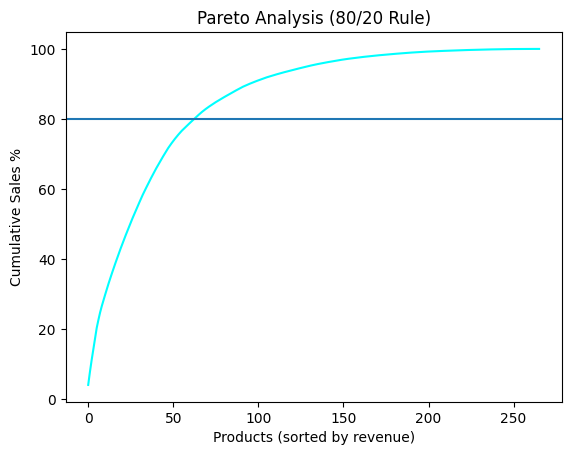

In [25]:
plt.figure()
plt.plot(df['CumSales%'],color='aqua')
plt.axhline(y=80) 
plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("Products (sorted by revenue)")
plt.ylabel("Cumulative Sales %")
plt.show()

In [26]:
top_80 = df[df['CumSales%'] <= 80]
print("Number of products contributing to 80% revenue:", len(top_80))
print("Total products:", len(df))
print("Percentage of products:", len(top_80)/len(df)*100)

Number of products contributing to 80% revenue: 63
Total products: 266
Percentage of products: 23.684210526315788
